In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
data = {
    'jam_belajar': [2,3,4,5,6,7,8,3,5,7],
    'jumlah_kehadiran': [80,85,90,75,95,85,100,70,88,92],
    'jumlah_tugas': [70,75,80,65,85,78,90,60,82,88],
    'nilai_akhir': [65,70,75,68,85,80,90,60,78,88]
}

df = pd.DataFrame(data)
print(df)

   jam_belajar  jumlah_kehadiran  jumlah_tugas  nilai_akhir
0            2                80            70           65
1            3                85            75           70
2            4                90            80           75
3            5                75            65           68
4            6                95            85           85
5            7                85            78           80
6            8               100            90           90
7            3                70            60           60
8            5                88            82           78
9            7                92            88           88


In [3]:
X = df[['jam_belajar', 'jumlah_kehadiran', 'jumlah_tugas']]
y = df['nilai_akhir']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
print("Intercept:", model.intercept_)
print("Koefisien [belajar, hadir, tugas]:", model.coef_)

Intercept: 13.179018206289484
Koefisien [belajar, hadir, tugas]: [ 1.98329969 -0.0487623   0.73988469]


In [7]:
y_pred = model.predict(X_test)

print("Data Testing:")
print(X_test)
print("Nilai Asli:", y_test.values)
print("Nilai Prediksi:", y_pred)

Data Testing:
   jam_belajar  jumlah_kehadiran  jumlah_tugas
8            5                88            82
1            3                85            75
Nilai Asli: [78 70]
Nilai Prediksi: [79.47497863 70.47547335]


In [8]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.9752259871592059
MSE: 1.200818429038431
RMSE: 1.0958186113761852


In [9]:
prediksi = model.predict([[6, 90, 85]])
print("Prediksi nilai akhir (6 jam belajar, 90% hadir, tugas 85):", prediksi[0])

Prediksi nilai akhir (6 jam belajar, 90% hadir, tugas 85): 83.58040777723214


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


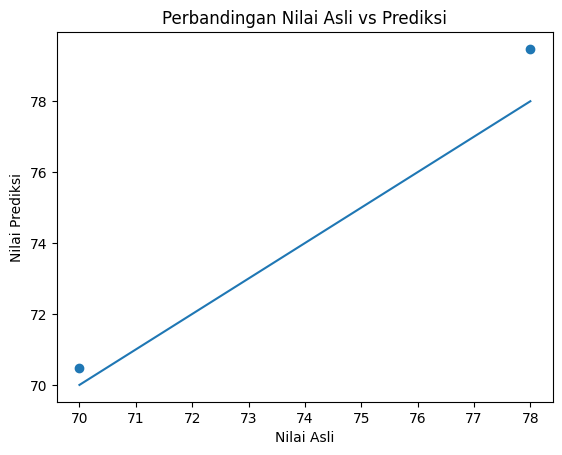

In [10]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Asli")
plt.ylabel("Nilai Prediksi")
plt.title("Perbandingan Nilai Asli vs Prediksi")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

Analisis Prediksi Nilai Mahasiswa Menggunakan Regresi Linear Berganda
1. Deskripsi Data dan Variabel
Tugas ini bertujuan untuk membangun model yang dapat memprediksi nilai akhir mahasiswa berdasarkan tiga faktor utama sebagai variabel bebas (fitur), yaitu: jam belajar, jumlah kehadiran, dan jumlah tugas. Data yang digunakan mencakup variasi performa mahasiswa, mulai dari yang memiliki jam belajar rendah (2 jam) hingga tinggi (8 jam), dengan rentang nilai akhir antara 60 hingga 90.

2. Implementasi Model Machine Learning
Model yang digunakan adalah Multiple Linear Regression (Regresi Linear Berganda) dari pustaka Scikit-Learn. Proses dimulai dengan pembagian data menjadi data latih (training set) dan data uji (testing set) dengan proporsi 80:20. Model kemudian dilatih menggunakan data latih untuk menentukan hubungan matematis antara fitur-fitur akademik dengan nilai akhir yang diperoleh.

3. Hasil Koefisien dan Persamaan Regresi
Berdasarkan hasil pelatihan model, diperoleh nilai Intercept sebesar kurang lebih 13.18. Selain itu, model menghasilkan koefisien untuk masing-masing variabel sebagai berikut:

- Jam Belajar: ~1.98

- Jumlah Kehadiran: ~ -0.049

- Jumlah Tugas: ~0.74
Dari koefisien ini, terlihat bahwa jam belajar memberikan pengaruh positif paling besar terhadap peningkatan nilai akhir mahasiswa dibandingkan faktor lainnya dalam dataset ini.

4. Evaluasi Performa Model
Performa model diuji menggunakan data uji yang menghasilkan metrik evaluasi sebagai berikut:

- Mean Absolute Error (MAE): ~0.97

- Mean Squared Error (MSE): ~1.20

- Root Mean Squared Error (RMSE): ~1.09
Nilai error yang relatif kecil (RMSE sekitar 1.09) menunjukkan bahwa prediksi model cukup akurat dan mendekati nilai asli mahasiswa pada data pengujian. Sebagai contoh, pada data uji dengan nilai asli 78, model berhasil memprediksi nilai 79.47.

5. Simulasi Prediksi dan Visualisasi
Model juga diuji untuk memprediksi skenario baru: seorang mahasiswa yang belajar selama 6 jam, hadir 90%, dan mengumpulkan 85 tugas diprediksi akan mendapatkan nilai akhir sebesar 83.58. Untuk memperkuat analisis, disertakan visualisasi scatter plot yang membandingkan nilai asli dengan nilai prediksi, di mana titik-titik data berada sangat dekat dengan garis diagonal, menandakan tingkat akurasi model yang tinggi dalam menangkap pola data akademik tersebut.